# 국내 기업 뉴스 이벤트 유형별 단기 초과수익률 분석

## 프로젝트 개요

본 프로젝트에서는 국내 주요 상장기업의 종목 뉴스를 이벤트 유형으로 분류하고, 뉴스 발생 이후 해당 종목의 단기 수익률이 시장 대비 어떻게 달라지는지 분석하였습니다.  
분석 기준은 개별 종목 수익률에서 KOSPI 수익률을 차감한 **초과수익률**이며, 이를 통해 단순 주가 상승률이 아니라 같은 기간의 시장 흐름을 제외한 종목 고유의 반응을 확인하고자 하였습니다.

뉴스 데이터는 네이버 금융 종목뉴스의 제목과 발생 시각을 사용하였습니다. 제목 기반 분석은 기사 본문 전체의 문맥을 반영하지 못한다는 한계가 있지만, 여러 기업의 이벤트를 동일한 기준으로 빠르게 비교할 수 있다는 장점이 있습니다.

## 연구 질문

1. 기업 뉴스 이벤트 이후 단기 초과수익률은 이벤트 유형별로 차이가 있는지 확인하였습니다.
2. 뉴스 발생 전후의 평균 초과수익률과 누적 초과수익률이 어떤 흐름을 보이는지 살펴보았습니다.
3. 뉴스 이벤트 유형, 제목 방향성, 직전 주가 흐름이 이후 초과수익률이 상대적으로 좋은 이벤트를 선별하는 데 도움이 되는지 확인하였습니다.

## 분석 흐름

1. 분석 대상 종목과 KOSPI 지수 데이터를 수집하였습니다.
2. 네이버 금융 종목뉴스에서 뉴스 제목과 발생 시각을 수집하였습니다.
3. 뉴스 제목을 이벤트 유형과 간단한 방향성 지표로 분류하였습니다.
4. 뉴스 발생 시각을 실제 주가 반응이 나타날 거래일에 맞추었습니다.
5. 이벤트 이후 1일, 3일, 5일 초과수익률을 계산하였습니다.
6. 이벤트 전후 일별 초과수익률과 누적 초과수익률을 확인하였습니다.
7. 이벤트 유형별 평균, 중앙값, 양수 비율, 신뢰구간, p-value를 비교하였습니다.
8. 기본 분류 모델을 사용하여 이벤트 정보의 선별 가능성을 점검하였습니다.


## 1. 분석 환경

주가 데이터 수집, 뉴스 크롤링, 전처리, 시각화, 통계 검정, 기본 모델 비교에 필요한 라이브러리를 불러왔습니다.


In [1]:
# 처음 실행하는 환경에서 필요한 경우 한 번만 실행합니다.
# !pip install finance-datareader beautifulsoup4 scikit-learn scipy openpyxl

import time
import math
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from IPython.display import display

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    stats = None
    SCIPY_AVAILABLE = False

try:
    import FinanceDataReader as fdr
except ImportError:
    raise ImportError("FinanceDataReader가 설치되어 있지 않습니다. 위의 설치 코드를 먼저 실행해 주세요.")

warnings.filterwarnings("ignore")

# Windows 환경에서 한글이 깨지지 않도록 설정합니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def up_ratio(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return (x > 0).mean()


def bootstrap_mean_ci(values, n_boot=2000, random_state=42):
    values = pd.Series(values).dropna().astype(float).values

    if len(values) < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(random_state)
    boot_means = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(sample.mean())

    return np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)


def one_sample_mean_test(values):
    values = pd.Series(values).dropna().astype(float)

    if len(values) < 2:
        return {
            "sample_count": len(values),
            "mean": values.mean() if len(values) else np.nan,
            "std": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan
        }

    mean_value = values.mean()
    std_value = values.std(ddof=1)
    standard_error = std_value / np.sqrt(len(values))

    if standard_error == 0 or pd.isna(standard_error):
        t_stat = np.nan
        p_value = np.nan
    else:
        t_stat = mean_value / standard_error

        if SCIPY_AVAILABLE:
            p_value = stats.ttest_1samp(values, popmean=0, nan_policy="omit").pvalue
        else:
            # scipy가 없는 환경에서는 표본이 충분하다는 가정 아래 정규근사 p값을 사용합니다.
            p_value = math.erfc(abs(t_stat) / np.sqrt(2))

    return {
        "sample_count": len(values),
        "mean": mean_value,
        "std": std_value,
        "t_stat": t_stat,
        "p_value": p_value
    }


def format_percent_columns(df, percent_cols):
    result = df.copy()

    for col in percent_cols:
        if col in result.columns:
            result[col] = result[col] * 100

    return result


## 2. 분석 대상과 기준 설정

분석 기간은 2023년 이후로 설정하였습니다. 주가 데이터는 가능한 전체 기간을 사용하고, 뉴스 데이터는 네이버 금융 종목뉴스에서 실제로 수집되는 범위 안에서 사용하였습니다.

분석 대상은 국내 대형주와 뉴스가 꾸준히 발생하는 주요 종목으로 구성하였습니다. 종목 수를 과도하게 늘리면 수집 시간이 길어지기 때문에, 재현성과 실행 부담을 함께 고려하여 표본을 정하였습니다.

이벤트 스터디는 뉴스 기준일 전 3거래일부터 후 5거래일까지 확인하였습니다. 단기 반응을 보기 위해 1일, 3일, 5일 초과수익률을 함께 계산하였습니다.


In [2]:
START_DATE = "2023-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

MARKET_INDEX = "KS11"          # KOSPI 지수를 시장 기준으로 사용합니다.
MAX_NEWS_PAGES = 45            # 종목별로 확인할 네이버 금융 뉴스 페이지 수입니다.
MIN_EVENT_SAMPLES = 5          # 이벤트별 결과를 표시할 최소 표본 수입니다.
MODEL_MIN_ROWS = 60            # 모델 비교를 진행할 최소 데이터 수입니다.
RANDOM_STATE = 42
BOOTSTRAP_N = 2000

# 이벤트 스터디에서 확인할 거래일 기준 구간입니다.
EVENT_WINDOW_START = -3
EVENT_WINDOW_END = 5

STOCKS = {
    "005930": "삼성전자",
    "000660": "SK하이닉스",
    "373220": "LG에너지솔루션",
    "207940": "삼성바이오로직스",
    "005380": "현대차",
    "000270": "기아",
    "068270": "셀트리온",
    "005490": "POSCO홀딩스",
    "051910": "LG화학",
    "006400": "삼성SDI",
    "035420": "NAVER",
    "035720": "카카오",
    "105560": "KB금융",
    "055550": "신한지주",
    "032830": "삼성생명",
    "012330": "현대모비스",
    "066570": "LG전자",
    "096770": "SK이노베이션",
    "003670": "포스코퓨처엠",
    "028260": "삼성물산",
    "017670": "SK텔레콤",
    "034020": "두산에너빌리티",
    "018260": "삼성에스디에스",
    "003550": "LG",
    "086790": "하나금융지주",
    "000810": "삼성화재",
    "033780": "KT&G",
    "009150": "삼성전기",
    "010130": "고려아연",
    "352820": "하이브",
    "316140": "우리금융지주",
    "024110": "기업은행",
    "030200": "KT",
    "009540": "HD한국조선해양",
    "010140": "삼성중공업",
    "042660": "한화오션",
    "011200": "HMM",
    "047810": "한국항공우주",
    "090430": "아모레퍼시픽",
    "086280": "현대글로비스",
    "011170": "롯데케미칼",
    "010950": "S-Oil",
    "302440": "SK바이오사이언스",
    "326030": "SK바이오팜",
    "128940": "한미약품",
    "259960": "크래프톤",
    "323410": "카카오뱅크",
    "377300": "카카오페이",
    "138040": "메리츠금융지주",
    "271560": "오리온",
    "241560": "두산밥캣",
    "011070": "LG이노텍",
    "267260": "HD현대일렉트릭",
    "064350": "현대로템",
    "086520": "에코프로",
    "247540": "에코프로비엠",
    "196170": "알테오젠",
    "028300": "HLB",
    "277810": "레인보우로보틱스",
}

print("분석 기간:", START_DATE, "~", END_DATE)
print("종목 수:", len(STOCKS))
print("종목뉴스 확인 페이지 수:", MAX_NEWS_PAGES)
print("이벤트 스터디 구간:", EVENT_WINDOW_START, "~", EVENT_WINDOW_END, "거래일")


분석 기간: 2023-01-01 ~ 2026-04-27
종목 수: 59
종목뉴스 확인 페이지 수: 45
이벤트 스터디 구간: -3 ~ 5 거래일


## 3. 주가와 시장지수 데이터 구성

종목별 종가와 거래량을 가져온 뒤 KOSPI 지수 수익률을 결합하였습니다. 이후 뉴스 발생일 기준으로 1일, 3일, 5일 뒤의 개별 종목 수익률과 시장 수익률을 계산하였습니다.

초과수익률은 다음과 같이 정의하였습니다.

- 1일 초과수익률 = 종목 1일 수익률 - KOSPI 1일 수익률
- 3일 초과수익률 = 종목 3일 수익률 - KOSPI 3일 수익률
- 5일 초과수익률 = 종목 5일 수익률 - KOSPI 5일 수익률

이벤트 스터디에서는 일별 종목 수익률에서 일별 시장 수익률을 뺀 값을 일별 초과수익률로 사용하였습니다.


In [3]:
market = fdr.DataReader(MARKET_INDEX, START_DATE, END_DATE).reset_index()
market = market.rename(columns={"Date": "date", "Close": "market_close"})
market["date"] = pd.to_datetime(market["date"]).dt.normalize()

market = market[["date", "market_close"]].copy()
market["market_daily_ret"] = market["market_close"].pct_change()
market["market_ret_1d"] = market["market_close"].shift(-1) / market["market_close"] - 1
market["market_ret_3d"] = market["market_close"].shift(-3) / market["market_close"] - 1
market["market_ret_5d"] = market["market_close"].shift(-5) / market["market_close"] - 1

price_list = []

for code, name in STOCKS.items():
    try:
        df = fdr.DataReader(code, START_DATE, END_DATE).reset_index()

        if df.empty:
            print(name, "주가 데이터 없음")
            continue

        df = df.rename(columns={
            "Date": "date",
            "Close": "close",
            "Volume": "volume"
        })

        df["date"] = pd.to_datetime(df["date"]).dt.normalize()
        df["code"] = code
        df["name"] = name

        df = df[["date", "code", "name", "close", "volume"]].copy()

        # 뉴스가 나오기 전의 간단한 주가 흐름입니다.
        df["daily_ret"] = df["close"].pct_change()
        df["past_ret_1d"] = df["close"].pct_change(1)
        df["past_ret_5d"] = df["close"].pct_change(5)
        df["volume_ratio_5d"] = df["volume"] / df["volume"].rolling(5).mean()

        # 뉴스 이후 반응입니다.
        df["ret_1d"] = df["close"].shift(-1) / df["close"] - 1
        df["ret_3d"] = df["close"].shift(-3) / df["close"] - 1
        df["ret_5d"] = df["close"].shift(-5) / df["close"] - 1

        df = df.merge(market, on="date", how="left")

        df["daily_abret"] = df["daily_ret"] - df["market_daily_ret"]
        df["abret_1d"] = df["ret_1d"] - df["market_ret_1d"]
        df["abret_3d"] = df["ret_3d"] - df["market_ret_3d"]
        df["abret_5d"] = df["ret_5d"] - df["market_ret_5d"]

        price_list.append(df)

    except Exception as e:
        print(name, "주가 수집 오류:", e)

if price_list:
    price_all = pd.concat(price_list, ignore_index=True)
else:
    price_all = pd.DataFrame()

price_all = price_all.replace([np.inf, -np.inf], np.nan)
price_all = price_all.dropna(subset=["abret_1d", "abret_3d", "abret_5d"])

if price_all.empty:
    print("주가 데이터가 없습니다.")
else:
    latest_usable_date = price_all["date"].max()
    print("주가 데이터 행 수:", len(price_all))
    print("5일 뒤 수익률까지 계산 가능한 마지막 날짜:", latest_usable_date.date())
    display(price_all.head())


주가 데이터 행 수: 47436
5일 뒤 수익률까지 계산 가능한 마지막 날짜: 2026-04-20


,date,code,name,close,volume,daily_ret,past_ret_1d,past_ret_5d,volume_ratio_5d,ret_1d,...,ret_5d,market_close,market_daily_ret,market_ret_1d,market_ret_3d,market_ret_5d,daily_abret,abret_1d,abret_3d,abret_5d
0,2023-01-02,005930,삼성전자,55500,10031448,NaN,NaN,NaN,NaN,-0.001802,...,0.093694,2225.67,NaN,-0.003141,0.017514,0.055947,NaN,0.001339,0.031135,0.037746
1,2023-01-03,005930,삼성전자,55400,13547030,-0.001802,-0.001802,NaN,NaN,0.043321,...,0.090253,2218.68,-0.003141,0.016812,0.032132,0.059779,0.001339,0.026510,0.032850,0.030474
2,2023-01-04,005930,삼성전자,57800,20188071,0.043321,0.043321,NaN,NaN,0.006920,...,0.046713,2255.98,0.016812,0.003843,0.041760,0.045900,0.026510,0.003077,0.008413,0.000813
3,2023-01-05,005930,삼성전자,58200,15682826,0.006920,0.006920,NaN,NaN,0.013746,...,0.039519,2264.65,0.003843,0.011181,0.038266,0.044356,0.003077,0.002565,-0.000466,-0.004837
4,2023-01-06,005930,삼성전자,59000,17334989,0.013746,0.013746,NaN,1.12881,0.028814,...,0.030508,2289.97,0.011181,0.026297,0.030376,0.041974,0.002565,0.002516,-0.004952,-0.011466


## 4. 뉴스 제목 수집

뉴스 데이터는 네이버 금융의 종목별 뉴스 제목을 사용하였습니다. 종목별 뉴스 페이지는 기업과 직접 연결된 기사 위주로 구성되어 있어 일반 검색 결과보다 종목 관련성이 높고, 제목과 발생 시각을 비교적 일정한 형식으로 가져올 수 있습니다.

네이버 금융 종목뉴스는 최신 기사 중심으로 제공되기 때문에, 설정한 주가 분석 시작일보다 실제 뉴스 수집 범위가 짧을 수 있습니다. 따라서 결과를 해석하기 전에 뉴스 데이터가 어느 기간에 집중되어 있는지 먼저 확인하였습니다.


In [4]:
def collect_naver_finance_news(code, name, max_pages=30):
    news_rows = []
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": f"https://finance.naver.com/item/main.naver?code={code}",
        "Accept-Language": "ko-KR,ko;q=0.9,en-US;q=0.8,en;q=0.7",
    }

    start_date = pd.to_datetime(START_DATE)
    stop_count = 0

    for page in range(1, max_pages + 1):
        url = f"https://finance.naver.com/item/news_news.naver?code={code}&page={page}&sm=title_entity_id.basic&clusterId="

        try:
            response = requests.get(url, headers=headers, timeout=10)
            response.encoding = "euc-kr"

            if response.status_code != 200:
                continue

            soup = BeautifulSoup(response.text, "html.parser")
            page_rows = []

            for row in soup.select("tr"):
                title_tag = row.select_one("td.title a")
                date_tag = row.select_one("td.date")

                if title_tag is None or date_tag is None:
                    continue

                title = " ".join(title_tag.get_text(" ", strip=True).split())
                date_text = date_tag.get_text(" ", strip=True)
                news_time = pd.to_datetime(date_text, errors="coerce")

                if pd.isna(news_time) or title == "":
                    continue

                page_rows.append({
                    "code": code,
                    "name": name,
                    "news_time": news_time,
                    "title": title,
                    "source": "naver_finance"
                })

            if len(page_rows) == 0:
                stop_count += 1
            else:
                stop_count = 0
                news_rows.extend(page_rows)

            # 설정한 시작일보다 오래된 뉴스가 나오면 해당 종목의 수집을 멈춥니다.
            page_dates = [row["news_time"] for row in page_rows]
            if len(page_dates) > 0 and min(page_dates) < start_date:
                break

            # 빈 페이지가 이어지면 멈춥니다.
            if stop_count >= 3:
                break

            time.sleep(0.08)

        except Exception:
            continue

    return pd.DataFrame(news_rows)


In [5]:
news_list = []

for i, (code, name) in enumerate(STOCKS.items(), start=1):
    news_df = collect_naver_finance_news(code, name, MAX_NEWS_PAGES)

    if not news_df.empty:
        news_list.append(news_df)

    print(f"{i:02d}/{len(STOCKS)} {name}: {len(news_df)}건")

if news_list:
    news_all = pd.concat(news_list, ignore_index=True)
else:
    news_all = pd.DataFrame(columns=["code", "name", "news_time", "title", "source"])

news_all["news_time"] = pd.to_datetime(news_all["news_time"], errors="coerce")
news_all = news_all.dropna(subset=["news_time", "title"])
news_all = news_all.drop_duplicates(["code", "news_time", "title"])

start_date = pd.to_datetime(START_DATE)

if not price_all.empty:
    end_date = latest_usable_date + pd.Timedelta(days=1)
else:
    end_date = pd.to_datetime(END_DATE) + pd.Timedelta(days=1)

news_all = news_all[
    (news_all["news_time"] >= start_date) &
    (news_all["news_time"] < end_date)
].copy()

news_all["year"] = news_all["news_time"].dt.year

print("전체 뉴스 수:", len(news_all))

if len(news_all) > 0:
    display(news_all["source"].value_counts())
    display(news_all["year"].value_counts().sort_index())
    display(news_all.head())
else:
    print("뉴스가 수집되지 않았습니다. 인터넷 연결이나 수집 주소를 확인해 주세요.")

01/59 삼성전자: 942건
02/59 SK하이닉스: 881건
03/59 LG에너지솔루션: 692건
04/59 삼성바이오로직스: 779건
05/59 현대차: 963건
06/59 기아: 1326건
07/59 셀트리온: 1473건
08/59 POSCO홀딩스: 1057건
09/59 LG화학: 1030건
10/59 삼성SDI: 1069건
11/59 NAVER: 1270건
12/59 카카오: 1070건
13/59 KB금융: 947건
14/59 신한지주: 953건
15/59 삼성생명: 1039건
16/59 현대모비스: 886건
17/59 LG전자: 1527건
18/59 SK이노베이션: 819건
19/59 포스코퓨처엠: 1374건
20/59 삼성물산: 1145건
21/59 SK텔레콤: 1482건
22/59 두산에너빌리티: 757건
23/59 삼성에스디에스: 1520건
24/59 LG: 1495건
25/59 하나금융지주: 1002건
26/59 삼성화재: 1113건
27/59 KT&G: 1230건
28/59 삼성전기: 870건
29/59 고려아연: 1305건
30/59 하이브: 798건
31/59 우리금융지주: 920건
32/59 기업은행: 1239건
33/59 KT: 1257건
34/59 HD한국조선해양: 1067건
35/59 삼성중공업: 1216건
36/59 한화오션: 1152건
37/59 HMM: 988건
38/59 한국항공우주: 1010건
39/59 아모레퍼시픽: 855건
40/59 현대글로비스: 1329건
41/59 롯데케미칼: 1024건
42/59 S-Oil: 1113건
43/59 SK바이오사이언스: 1333건
44/59 SK바이오팜: 1090건
45/59 한미약품: 1107건
46/59 크래프톤: 1127건
47/59 카카오뱅크: 1270건
48/59 카카오페이: 1181건
49/59 메리츠금융지주: 981건
50/59 오리온: 1188건
51/59 두산밥캣: 1615건
52/59 LG이노텍: 1225건
53/59 HD현대일렉트릭: 856건
54/59 현대로템:

source
naver_finance    15607
Name: count, dtype: int64

year
2025      208
2026    15399
Name: count, dtype: int64

,code,name,news_time,title,source,year
3100,207940,삼성바이오로직스,2026-04-20 18:13:00,항암 신약 위탁연구부터 생산까지… 삼성바이오 역량 알린다,naver_finance,2026
3101,207940,삼성바이오로직스,2026-04-20 14:38:00,"삼성바이오, 미국암연구학회 첫 참가…CRDMO 역량 소개 방점",naver_finance,2026
3103,207940,삼성바이오로직스,2026-04-20 13:49:00,"삼성바이오로직스, AACR 첫 참가…초기 신약개발 시장 정조준",naver_finance,2026
3104,207940,삼성바이오로직스,2026-04-20 11:41:00,"삼성바이오, 美암연구학회 첫 참가…CDMO 역량 소개",naver_finance,2026
3105,207940,삼성바이오로직스,2026-04-20 10:46:00,"삼성바이오로직스, AACR 첫 참가...초기 개발 '선점 전략' 본격...",naver_finance,2026


## 4-1. 수집 데이터 범위 확인

주가 데이터와 뉴스 데이터의 실제 시작일과 종료일을 비교하였습니다.  
주가 데이터 기간이 길더라도 뉴스 데이터가 특정 기간에 집중되어 있다면, 최종 해석 역시 해당 뉴스 수집 기간을 중심으로 제한해야 합니다.


In [6]:
coverage_rows = []

if not price_all.empty:
    coverage_rows.append({
        "구분": "주가 데이터",
        "시작일": price_all["date"].min().date(),
        "종료일": price_all["date"].max().date(),
        "행 수": len(price_all)
    })

if not news_all.empty:
    coverage_rows.append({
        "구분": "뉴스 데이터",
        "시작일": news_all["news_time"].min().date(),
        "종료일": news_all["news_time"].max().date(),
        "행 수": len(news_all)
    })

coverage_check = pd.DataFrame(coverage_rows)
display(coverage_check)

if not news_all.empty:
    display(news_all["year"].value_counts().sort_index().rename("뉴스 수"))


,구분,시작일,종료일,행 수
0,주가 데이터,2023-01-02,2026-04-20,47436
1,뉴스 데이터,2025-12-02,2026-04-20,15607


year
2025      208
2026    15399
Name: 뉴스 수, dtype: int64

## 5. 뉴스 이벤트 분류

뉴스 제목은 표현이 다양하므로 그대로 비교하기 어렵습니다. 본 분석에서는 주가 반응과 관련될 가능성이 있는 단어를 기준으로 뉴스 제목을 몇 가지 이벤트 유형으로 나누었습니다.

이벤트 유형은 `실적`, `수주계약`, `악재`, `목표가리포트`, `정책테마`처럼 뉴스의 성격을 나타내는 범주로 구성하였습니다. 제목 안에 긍정적 단어와 부정적 단어가 얼마나 포함되어 있는지도 함께 계산하여 간단한 방향성 지표로 사용하였습니다.

키워드 기반 분류는 문맥을 완전히 이해하지 못한다는 한계가 있습니다. 대신 분류 기준이 명확하고, 결과를 직접 확인하기 쉽다는 장점이 있습니다.


In [7]:
EVENT_KEYWORDS = {
    "악재": [
        "소송", "압수수색", "조사", "제재", "과징금", "리콜", "급락",
        "부진", "우려", "손실", "횡령", "배임", "파업", "하향", "감소",
        "적자", "쇼크", "중단", "철회", "징계", "고발", "불확실", "경고"
    ],
    "자금조달": [
        "유상증자", "전환사채", "CB", "BW", "신주", "자금조달", "증자",
        "사채", "차입", "발행", "주주배정"
    ],
    "수주계약": [
        "수주", "공급계약", "계약", "납품", "체결", "선정",
        "MOU", "협력", "공급", "파트너십", "공동개발", "공동 개발"
    ],
    "실적": [
        "실적", "영업이익", "매출", "순이익", "흑자", "어닝",
        "분기", "이익", "컨센서스", "잠정", "매출액", "분기 최대"
    ],
    "투자증설": [
        "투자", "증설", "공장", "생산", "라인", "설비", "CAPA", "신사업",
        "시설", "공급망", "착공", "준공", "양산"
    ],
    "목표가리포트": [
        "목표가", "투자의견", "매수", "상향", "리포트", "커버리지",
        "추천", "최선호주", "톱픽", "목표주가"
    ],
    "바이오": [
        "임상", "허가", "승인", "FDA", "신약", "치료제", "바이오",
        "품목허가", "시판", "허가신청", "임상시험"
    ],
    "정책테마": [
        "정부", "정책", "규제", "지원", "수혜", "테마", "국책",
        "보조금", "개편", "세제", "산업부", "금융위"
    ]
}

POSITIVE_WORDS = [
    "상향", "증가", "개선", "호조", "흑자", "수주", "계약", "승인",
    "허가", "성장", "확대", "강세", "최대", "돌파", "매수", "추천",
    "기대", "수혜", "신고가", "반등", "최선호", "호평"
]

NEGATIVE_WORDS = [
    "하향", "감소", "부진", "적자", "우려", "손실", "급락", "약세",
    "리콜", "제재", "소송", "압수수색", "중단", "철회", "쇼크", "악화",
    "파업", "고발", "과징금", "불확실", "경고"
]

EVENT_SCORE = {
    "악재": -1,
    "자금조달": -1,
    "수주계약": 1,
    "실적": 1,
    "투자증설": 1,
    "목표가리포트": 1,
    "바이오": 1,
    "정책테마": 1,
    "기타": 0,
}


def count_words(text, words):
    text = str(text)
    return sum(1 for word in words if word in text)


def classify_event(title):
    text = str(title)
    event_counts = {}

    for event_name, keywords in EVENT_KEYWORDS.items():
        event_counts[event_name] = count_words(text, keywords)

    best_event = max(event_counts, key=event_counts.get)
    best_count = event_counts[best_event]

    if best_count == 0:
        return "기타", 0

    return best_event, best_count


def get_tone_score(title):
    positive_count = count_words(title, POSITIVE_WORDS)
    negative_count = count_words(title, NEGATIVE_WORDS)
    return positive_count - negative_count


def label_tone(score):
    if score > 0:
        return "긍정"
    if score < 0:
        return "부정"
    return "중립"


In [8]:
if news_all.empty:
    news_labeled = news_all.copy()
    news_event = news_all.copy()
    print("분류할 뉴스가 없습니다.")
else:
    event_result = news_all["title"].apply(classify_event)

    news_labeled = news_all.copy()
    news_labeled["main_event"] = event_result.apply(lambda x: x[0])
    news_labeled["event_word_count"] = event_result.apply(lambda x: x[1])
    news_labeled["event_score"] = news_labeled["main_event"].map(EVENT_SCORE).fillna(0)

    news_labeled["tone_score"] = news_labeled["title"].apply(get_tone_score)
    news_labeled["tone_label"] = news_labeled["tone_score"].apply(label_tone)

    # 이벤트 반응 분석은 이벤트 유형이 분류된 뉴스만 사용합니다.
    news_event = news_labeled[news_labeled["main_event"] != "기타"].copy()

    print("전체 뉴스 수:", len(news_labeled))
    print("이벤트 뉴스 수:", len(news_event))
    display(news_labeled["main_event"].value_counts())
    display(news_event["tone_label"].value_counts())
    display(news_event.head())

전체 뉴스 수: 15607
이벤트 뉴스 수: 5597


main_event
기타        10010
수주계약       1182
실적          900
바이오         810
투자증설        798
악재          677
정책테마        659
목표가리포트      413
자금조달        158
Name: count, dtype: int64

tone_label
중립    3353
긍정    1684
부정     560
Name: count, dtype: int64

,code,name,news_time,title,source,year,main_event,event_word_count,event_score,tone_score,tone_label
3100,207940,삼성바이오로직스,2026-04-20 18:13:00,항암 신약 위탁연구부터 생산까지… 삼성바이오 역량 알린다,naver_finance,2026,바이오,2,1,0,중립
3101,207940,삼성바이오로직스,2026-04-20 14:38:00,"삼성바이오, 미국암연구학회 첫 참가…CRDMO 역량 소개 방점",naver_finance,2026,바이오,1,1,0,중립
3103,207940,삼성바이오로직스,2026-04-20 13:49:00,"삼성바이오로직스, AACR 첫 참가…초기 신약개발 시장 정조준",naver_finance,2026,바이오,2,1,0,중립
3104,207940,삼성바이오로직스,2026-04-20 11:41:00,"삼성바이오, 美암연구학회 첫 참가…CDMO 역량 소개",naver_finance,2026,바이오,1,1,0,중립
3105,207940,삼성바이오로직스,2026-04-20 10:46:00,"삼성바이오로직스, AACR 첫 참가...초기 개발 '선점 전략' 본격...",naver_finance,2026,바이오,1,1,0,중립


## 6. 뉴스 시간을 거래일에 맞추기

뉴스가 나온 시간에 따라 실제 주가 반응이 나타나는 거래일이 달라집니다.  
장중에 나온 뉴스는 해당 거래일의 반응으로 보고, 장 마감 이후에 나온 뉴스는 다음 거래일의 반응으로 처리하였습니다.

주말이나 휴장일에 나온 뉴스도 다음 거래일로 이동시켰습니다. 이후 5거래일 수익률까지 계산해야 하므로, 충분한 이후 가격 데이터가 없는 최근 뉴스는 분석 대상에서 제외하였습니다.


In [9]:
if price_all.empty:
    trading_days = np.array([], dtype="datetime64[ns]")
else:
    price_all["date"] = pd.to_datetime(price_all["date"]).dt.normalize()
    trading_days = np.array(sorted(price_all["date"].dropna().unique()), dtype="datetime64[ns]")


def get_event_trade_date(news_time):
    if pd.isna(news_time) or len(trading_days) == 0:
        return pd.NaT

    news_time = pd.Timestamp(news_time)
    base_date = news_time.normalize()

    # 장 마감 이후 뉴스는 다음 거래일 반응으로 봅니다.
    if (news_time.hour > 15) or (news_time.hour == 15 and news_time.minute >= 30):
        base_date = base_date + pd.Timedelta(days=1)

    idx = np.searchsorted(trading_days, np.datetime64(base_date))

    if idx >= len(trading_days):
        return pd.NaT

    return pd.Timestamp(trading_days[idx]).normalize()


if news_event.empty:
    print("거래일에 맞출 이벤트 뉴스가 없습니다.")
else:
    before_count = len(news_event)

    news_event["date"] = news_event["news_time"].apply(get_event_trade_date)
    news_event = news_event.dropna(subset=["date"]).copy()

    print("거래일 매칭 전 이벤트 뉴스 수:", before_count)
    print("거래일 매칭 후 이벤트 뉴스 수:", len(news_event))

    if len(news_event) > 0:
        display(news_event["date"].dt.year.value_counts().sort_index())
        display(news_event.head())

거래일 매칭 전 이벤트 뉴스 수: 5597
거래일 매칭 후 이벤트 뉴스 수: 5377


date
2025      69
2026    5308
Name: count, dtype: int64

,code,name,news_time,title,source,year,main_event,event_word_count,event_score,tone_score,tone_label,date
3101,207940,삼성바이오로직스,2026-04-20 14:38:00,"삼성바이오, 미국암연구학회 첫 참가…CRDMO 역량 소개 방점",naver_finance,2026,바이오,1,1,0,중립,2026-04-20
3103,207940,삼성바이오로직스,2026-04-20 13:49:00,"삼성바이오로직스, AACR 첫 참가…초기 신약개발 시장 정조준",naver_finance,2026,바이오,2,1,0,중립,2026-04-20
3104,207940,삼성바이오로직스,2026-04-20 11:41:00,"삼성바이오, 美암연구학회 첫 참가…CDMO 역량 소개",naver_finance,2026,바이오,1,1,0,중립,2026-04-20
3105,207940,삼성바이오로직스,2026-04-20 10:46:00,"삼성바이오로직스, AACR 첫 참가...초기 개발 '선점 전략' 본격...",naver_finance,2026,바이오,1,1,0,중립,2026-04-20
3106,207940,삼성바이오로직스,2026-04-20 10:45:00,"삼성바이오로직스, 세계 최대 암학회 참가…CRDMO 경쟁력 알려",naver_finance,2026,바이오,1,1,1,긍정,2026-04-20


## 7. 일 단위 이벤트 데이터 구성

같은 종목에서 같은 날 여러 개의 이벤트 뉴스가 발생할 수 있습니다. 따라서 뉴스 한 건을 하나의 관측치로 사용하지 않고, **종목-거래일 단위**로 묶어 분석용 데이터를 구성하였습니다.

하루 안에 발생한 이벤트 수, 대표 이벤트 유형, 이벤트 점수, 제목 방향성 점수, 이벤트 관련 단어 수를 함께 저장하였습니다. 이 데이터는 이후 이벤트 유형별 수익률 비교와 모델 학습의 기준으로 사용하였습니다.


In [10]:
event_cols = ["event_" + event_name for event_name in EVENT_KEYWORDS.keys()]

if news_event.empty:
    data = pd.DataFrame()
    dummy_cols = event_cols
    print("분석용 데이터를 만들 이벤트 뉴스가 없습니다.")
else:
    event_dummy = pd.get_dummies(news_event["main_event"], prefix="event").astype(int)
    news_event_with_dummy = pd.concat(
        [news_event.reset_index(drop=True), event_dummy.reset_index(drop=True)],
        axis=1
    )

    for col in event_cols:
        if col not in news_event_with_dummy.columns:
            news_event_with_dummy[col] = 0

    news_event_with_dummy["positive_news_count"] = (
        news_event_with_dummy["tone_label"] == "긍정"
    ).astype(int)
    news_event_with_dummy["negative_news_count"] = (
        news_event_with_dummy["tone_label"] == "부정"
    ).astype(int)

    dummy_cols = event_cols

    daily_event = news_event_with_dummy.groupby(["code", "name", "date"]).agg(
        news_count=("title", "count"),
        main_event=("main_event", lambda x: x.value_counts().index[0]),
        tone_label=("tone_label", lambda x: x.value_counts().index[0]),
        event_score_sum=("event_score", "sum"),
        event_word_count_sum=("event_word_count", "sum"),
        tone_score_sum=("tone_score", "sum"),
        tone_score_mean=("tone_score", "mean"),
        positive_news_count=("positive_news_count", "sum"),
        negative_news_count=("negative_news_count", "sum"),
        sample_titles=("title", lambda x: " / ".join(list(x)[:3]))
    ).reset_index()

    daily_dummy = news_event_with_dummy.groupby(["code", "name", "date"])[dummy_cols].sum().reset_index()
    daily_event = daily_event.merge(daily_dummy, on=["code", "name", "date"], how="left")

    data = daily_event.merge(
        price_all,
        on=["code", "name", "date"],
        how="inner"
    )

    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=["abret_1d", "abret_3d", "abret_5d"])
    data = data.sort_values("date").reset_index(drop=True)

    print("하루 단위 이벤트 데이터:", len(daily_event))
    print("분석용 데이터 행 수:", len(data))

    if len(data) < 100:
        print("분석용 데이터가 아직 적습니다. 결과는 예비 분석으로 보는 것이 좋습니다.")
    else:
        print("분석용 데이터는 이벤트별 비교가 가능한 수준입니다. 다만 모델 검증에는 표본 확대가 더 필요합니다.")

    display(data.head())

하루 단위 이벤트 데이터: 857
분석용 데이터 행 수: 857
분석용 데이터는 이벤트별 비교가 가능한 수준입니다. 다만 모델 검증에는 표본 확대가 더 필요합니다.


,code,name,date,news_count,main_event,tone_label,event_score_sum,event_word_count_sum,tone_score_sum,tone_score_mean,...,ret_5d,market_close,market_daily_ret,market_ret_1d,market_ret_3d,market_ret_5d,daily_abret,abret_1d,abret_3d,abret_5d
0,011200,HMM,2025-12-03,2,실적,중립,2,2,0,0.0,...,0.000000,4036.30,0.010356,-0.001930,0.029371,0.024453,-0.010356,-0.000551,-0.012001,-0.024453
1,011200,HMM,2025-12-05,1,자금조달,중립,-1,1,0,0.0,...,0.009732,4100.05,0.017758,0.013366,0.008524,0.016368,0.004630,-0.015799,-0.027989,-0.006636
2,011200,HMM,2025-12-08,1,정책테마,중립,1,1,0,0.0,...,0.009756,4154.85,0.013366,-0.002720,-0.010645,-0.015466,-0.015799,0.007598,0.005767,0.025222
3,302440,SK바이오사이언스,2025-12-08,5,정책테마,중립,5,5,0,0.0,...,0.000000,4154.85,0.013366,-0.002720,-0.010645,-0.015466,-0.031884,0.004607,0.003098,0.015466
4,302440,SK바이오사이언스,2025-12-09,2,바이오,중립,0,2,-1,-0.5,...,-0.020716,4143.55,-0.002720,-0.002063,0.005698,-0.034854,0.004607,-0.013002,-0.022647,0.014139


## 8. 이벤트별 초과수익률 비교

먼저 모델을 사용하기 전에 이벤트 유형별 평균 초과수익률을 비교하였습니다.  
초과수익률이 양수이면 같은 기간 시장보다 더 좋았다는 의미이고, 음수이면 시장보다 부진했다는 의미입니다.

평균값은 일부 극단값의 영향을 받을 수 있으므로 중앙값과 양수 비율을 함께 확인하였습니다. 표본 수가 작은 이벤트는 순위가 높게 나오더라도 일반화하기 어렵기 때문에 최소 표본 수 기준을 함께 두었습니다.


In [11]:
if data.empty:
    event_summary = pd.DataFrame()
    event_summary_filtered = pd.DataFrame()
    print("이벤트별로 비교할 데이터가 없습니다.")
else:
    event_summary = data.groupby("main_event").agg(
        sample_count=("abret_3d", "size"),
        abret_1d_mean=("abret_1d", "mean"),
        abret_3d_mean=("abret_3d", "mean"),
        abret_5d_mean=("abret_5d", "mean"),
        abret_3d_median=("abret_3d", "median"),
        up_ratio_3d=("abret_3d", up_ratio),
        tone_score_mean=("tone_score_mean", "mean")
    ).reset_index()

    test_rows = []

    for event_name, group in data.groupby("main_event"):
        ci_low, ci_high = bootstrap_mean_ci(
            group["abret_3d"],
            n_boot=BOOTSTRAP_N,
            random_state=RANDOM_STATE
        )
        test_result = one_sample_mean_test(group["abret_3d"])

        test_rows.append({
            "main_event": event_name,
            "abret_3d_ci_low": ci_low,
            "abret_3d_ci_high": ci_high,
            "abret_3d_t_stat": test_result["t_stat"],
            "abret_3d_p_value": test_result["p_value"]
        })

    event_test_summary = pd.DataFrame(test_rows)
    event_summary = event_summary.merge(event_test_summary, on="main_event", how="left")

    event_summary = event_summary.sort_values("abret_3d_mean", ascending=False)
    event_summary_filtered = event_summary[event_summary["sample_count"] >= MIN_EVENT_SAMPLES].copy()

    print("이벤트별 전체 요약")
    display(event_summary)

    print("최소 표본 수 이상인 이벤트")
    display(event_summary_filtered)

    positive_count = (event_summary_filtered["abret_3d_mean"] > 0).sum()
    print("평균 3일 초과수익률이 양수인 이벤트 수:", positive_count)


이벤트별 전체 요약


,main_event,sample_count,abret_1d_mean,abret_3d_mean,abret_5d_mean,abret_3d_median,up_ratio_3d,tone_score_mean,abret_3d_ci_low,abret_3d_ci_high,abret_3d_t_stat,abret_3d_p_value
2,수주계약,142,-0.003265,0.000213,-0.005079,-0.002654,0.471831,0.395545,-0.007788,0.008608,0.049013,0.960978
3,실적,145,-0.001272,-0.004360,-0.008399,-0.009955,0.406897,0.374629,-0.013491,0.005069,-0.912641,0.362957
0,목표가리포트,73,-0.002956,-0.005453,-0.020798,-0.017663,0.410959,0.887482,-0.015288,0.005002,-1.093373,0.277875
5,자금조달,27,0.001856,-0.009202,-0.020495,-0.013337,0.407407,0.070390,-0.025697,0.008775,-1.059205,0.299248
6,정책테마,102,-0.001490,-0.011129,-0.025801,-0.017386,0.362745,0.224943,-0.020808,-0.000447,-2.114060,0.036973
7,투자증설,114,-0.004349,-0.012718,-0.016223,-0.020220,0.324561,0.158518,-0.020066,-0.005465,-3.389758,0.000964
4,악재,134,-0.006492,-0.013698,-0.022890,-0.018262,0.358209,-0.503610,-0.021620,-0.005402,-3.384520,0.000937
1,바이오,120,-0.007744,-0.023402,-0.041153,-0.025071,0.308333,0.173798,-0.032111,-0.014521,-5.100548,0.000001


최소 표본 수 이상인 이벤트


,main_event,sample_count,abret_1d_mean,abret_3d_mean,abret_5d_mean,abret_3d_median,up_ratio_3d,tone_score_mean,abret_3d_ci_low,abret_3d_ci_high,abret_3d_t_stat,abret_3d_p_value
2,수주계약,142,-0.003265,0.000213,-0.005079,-0.002654,0.471831,0.395545,-0.007788,0.008608,0.049013,0.960978
3,실적,145,-0.001272,-0.004360,-0.008399,-0.009955,0.406897,0.374629,-0.013491,0.005069,-0.912641,0.362957
0,목표가리포트,73,-0.002956,-0.005453,-0.020798,-0.017663,0.410959,0.887482,-0.015288,0.005002,-1.093373,0.277875
5,자금조달,27,0.001856,-0.009202,-0.020495,-0.013337,0.407407,0.070390,-0.025697,0.008775,-1.059205,0.299248
6,정책테마,102,-0.001490,-0.011129,-0.025801,-0.017386,0.362745,0.224943,-0.020808,-0.000447,-2.114060,0.036973
7,투자증설,114,-0.004349,-0.012718,-0.016223,-0.020220,0.324561,0.158518,-0.020066,-0.005465,-3.389758,0.000964
4,악재,134,-0.006492,-0.013698,-0.022890,-0.018262,0.358209,-0.503610,-0.021620,-0.005402,-3.384520,0.000937
1,바이오,120,-0.007744,-0.023402,-0.041153,-0.025071,0.308333,0.173798,-0.032111,-0.014521,-5.100548,0.000001


평균 3일 초과수익률이 양수인 이벤트 수: 1


## 8-1. 이벤트 결과 해석 기준

이벤트별 평균 3일 초과수익률은 방향성을 확인하는 첫 번째 지표로 사용하였습니다.  
다만 평균값 하나만으로 이벤트 효과를 판단하기는 어렵습니다. 표본 수가 적거나 변동성이 큰 경우 한두 건의 사례가 평균값을 크게 움직일 수 있기 때문입니다.

따라서 본 프로젝트에서는 평균, 중앙값, 양수 비율, bootstrap 신뢰구간, p-value를 함께 확인하였습니다. p-value는 평균 초과수익률이 0과 다른지 살펴보는 보조 지표로 사용하였으며, 결과 해석은 표본 수와 신뢰구간을 함께 고려하였습니다.


In [12]:
if "event_summary" in globals() and not event_summary.empty:
    readable_event_summary = event_summary.copy()

    percent_cols = [
        "abret_1d_mean", "abret_3d_mean", "abret_5d_mean",
        "abret_3d_median", "up_ratio_3d",
        "abret_3d_ci_low", "abret_3d_ci_high"
    ]

    readable_event_summary = format_percent_columns(readable_event_summary, percent_cols)

    readable_event_summary["해석 기준"] = np.where(
        readable_event_summary["sample_count"] >= 20,
        "비교 가능",
        "참고용"
    )

    display(readable_event_summary.round(4))
else:
    print("이벤트 요약 데이터가 없습니다.")


,main_event,sample_count,abret_1d_mean,abret_3d_mean,abret_5d_mean,abret_3d_median,up_ratio_3d,tone_score_mean,abret_3d_ci_low,abret_3d_ci_high,abret_3d_t_stat,abret_3d_p_value,해석 기준
2,수주계약,142,-0.3265,0.0213,-0.5079,-0.2654,47.1831,0.3955,-0.7788,0.8608,0.0490,0.9610,비교 가능
3,실적,145,-0.1272,-0.4360,-0.8399,-0.9955,40.6897,0.3746,-1.3491,0.5069,-0.9126,0.3630,비교 가능
0,목표가리포트,73,-0.2956,-0.5453,-2.0798,-1.7663,41.0959,0.8875,-1.5288,0.5002,-1.0934,0.2779,비교 가능
5,자금조달,27,0.1856,-0.9202,-2.0495,-1.3337,40.7407,0.0704,-2.5697,0.8775,-1.0592,0.2992,비교 가능
6,정책테마,102,-0.1490,-1.1129,-2.5801,-1.7386,36.2745,0.2249,-2.0808,-0.0447,-2.1141,0.0370,비교 가능
7,투자증설,114,-0.4349,-1.2718,-1.6223,-2.0220,32.4561,0.1585,-2.0066,-0.5465,-3.3898,0.0010,비교 가능
4,악재,134,-0.6492,-1.3698,-2.2890,-1.8262,35.8209,-0.5036,-2.1620,-0.5402,-3.3845,0.0009,비교 가능
1,바이오,120,-0.7744,-2.3402,-4.1153,-2.5071,30.8333,0.1738,-3.2111,-1.4521,-5.1005,0.0000,비교 가능


## 9. 이벤트 스터디

이벤트 스터디는 뉴스가 발생한 거래일을 기준점으로 두고, 전후 며칠 동안의 일별 초과수익률을 확인하는 방법입니다.  
본 분석에서는 이벤트 기준일 전 3거래일부터 후 5거래일까지의 흐름을 살펴보았습니다.

복잡한 회귀모형 대신 종목 일별 수익률에서 KOSPI 일별 수익률을 뺀 값을 일별 초과수익률로 사용하였습니다. 이후 평균 초과수익률, 누적 초과수익률, 신뢰구간, p-value를 함께 확인하였습니다.


In [13]:
def event_window_col(offset):
    if offset < 0:
        return f"ar_m{abs(offset)}"
    if offset > 0:
        return f"ar_p{offset}"
    return "ar_0"


event_window_data = pd.DataFrame()
event_window_summary = pd.DataFrame()
car_summary = pd.DataFrame()
event_car_summary = pd.DataFrame()

if data.empty or price_all.empty:
    print("이벤트 스터디를 진행할 데이터가 없습니다.")
else:
    price_for_event = price_all.sort_values(["code", "date"]).copy()
    price_for_event["trade_idx"] = price_for_event.groupby("code").cumcount()

    event_window_data = data.copy()
    event_window_data = event_window_data.merge(
        price_for_event[["code", "date", "trade_idx"]],
        on=["code", "date"],
        how="left"
    )

    event_window_data["event_id"] = np.arange(len(event_window_data))
    offsets = list(range(EVENT_WINDOW_START, EVENT_WINDOW_END + 1))
    ar_cols = []

    for offset in offsets:
        col = event_window_col(offset)
        ar_cols.append(col)

        lookup = price_for_event[["code", "trade_idx", "daily_abret"]].copy()
        lookup = lookup.rename(columns={
            "trade_idx": "target_trade_idx",
            "daily_abret": col
        })

        target = event_window_data[["event_id", "code", "trade_idx"]].copy()
        target["target_trade_idx"] = target["trade_idx"] + offset

        merged = target.merge(
            lookup,
            on=["code", "target_trade_idx"],
            how="left"
        )

        event_window_data[col] = merged.set_index("event_id")[col]

    event_window_data["car_m1_p1"] = event_window_data[
        [event_window_col(-1), event_window_col(0), event_window_col(1)]
    ].sum(axis=1, min_count=3)

    event_window_data["car_0_p1"] = event_window_data[
        [event_window_col(0), event_window_col(1)]
    ].sum(axis=1, min_count=2)

    event_window_data["car_0_p3"] = event_window_data[
        [event_window_col(0), event_window_col(1), event_window_col(2), event_window_col(3)]
    ].sum(axis=1, min_count=4)

    event_window_data["car_0_p5"] = event_window_data[
        [event_window_col(i) for i in range(0, 6)]
    ].sum(axis=1, min_count=6)

    window_rows = []

    for offset in offsets:
        col = event_window_col(offset)
        values = event_window_data[col].dropna()
        ci_low, ci_high = bootstrap_mean_ci(values, n_boot=BOOTSTRAP_N, random_state=RANDOM_STATE + offset + 100)
        test_result = one_sample_mean_test(values)

        window_rows.append({
            "day_offset": offset,
            "sample_count": len(values),
            "mean_abret": values.mean(),
            "median_abret": values.median(),
            "up_ratio": up_ratio(values),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "t_stat": test_result["t_stat"],
            "p_value": test_result["p_value"]
        })

    event_window_summary = pd.DataFrame(window_rows)

    car_rows = []

    for label, col in {
        "CAR(-1,+1)": "car_m1_p1",
        "CAR(0,+1)": "car_0_p1",
        "CAR(0,+3)": "car_0_p3",
        "CAR(0,+5)": "car_0_p5"
    }.items():
        values = event_window_data[col].dropna()
        ci_low, ci_high = bootstrap_mean_ci(values, n_boot=BOOTSTRAP_N, random_state=RANDOM_STATE)
        test_result = one_sample_mean_test(values)

        car_rows.append({
            "window": label,
            "sample_count": len(values),
            "mean_car": values.mean(),
            "median_car": values.median(),
            "up_ratio": up_ratio(values),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "t_stat": test_result["t_stat"],
            "p_value": test_result["p_value"]
        })

    car_summary = pd.DataFrame(car_rows)

    car_group_rows = []

    for event_name, group in event_window_data.groupby("main_event"):
        values = group["car_0_p3"].dropna()
        ci_low, ci_high = bootstrap_mean_ci(values, n_boot=BOOTSTRAP_N, random_state=RANDOM_STATE)
        test_result = one_sample_mean_test(values)

        car_group_rows.append({
            "main_event": event_name,
            "sample_count": len(values),
            "mean_car_0_p3": values.mean(),
            "median_car_0_p3": values.median(),
            "up_ratio": up_ratio(values),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "t_stat": test_result["t_stat"],
            "p_value": test_result["p_value"]
        })

    event_car_summary = pd.DataFrame(car_group_rows)
    event_car_summary = event_car_summary.sort_values("mean_car_0_p3", ascending=False)
    event_car_summary_filtered = event_car_summary[
        event_car_summary["sample_count"] >= MIN_EVENT_SAMPLES
    ].copy()

    print("이벤트 전후 일별 평균 초과수익률")
    display(format_percent_columns(
        event_window_summary,
        ["mean_abret", "median_abret", "up_ratio", "ci_low", "ci_high"]
    ).round(4))

    print("누적 초과수익률 요약")
    display(format_percent_columns(
        car_summary,
        ["mean_car", "median_car", "up_ratio", "ci_low", "ci_high"]
    ).round(4))

    print("이벤트 유형별 CAR(0,+3)")
    display(format_percent_columns(
        event_car_summary_filtered,
        ["mean_car_0_p3", "median_car_0_p3", "up_ratio", "ci_low", "ci_high"]
    ).round(4))


이벤트 전후 일별 평균 초과수익률


,day_offset,sample_count,mean_abret,median_abret,up_ratio,ci_low,ci_high,t_stat,p_value
0,-3,857,-0.3158,-0.4473,43.4072,-0.5170,-0.1007,-2.9903,0.0029
1,-2,857,-0.3351,-0.4461,43.6406,-0.5304,-0.1373,-3.2418,0.0012
2,-1,857,-0.2764,-0.4289,43.1739,-0.4796,-0.0654,-2.6718,0.0077
3,0,857,-0.3011,-0.4201,43.4072,-0.5020,-0.1045,-3.0176,0.0026
4,1,814,-0.3583,-0.4425,42.2604,-0.5478,-0.1667,-3.6459,0.0003
5,2,775,-0.2946,-0.4294,43.3548,-0.4984,-0.0783,-2.7593,0.0059
6,3,736,-0.2464,-0.4217,42.7989,-0.4566,-0.0346,-2.2650,0.0238
7,4,693,-0.3977,-0.4797,41.4141,-0.6145,-0.1814,-3.5335,0.0004
8,5,657,-0.4803,-0.6129,39.5738,-0.6802,-0.2788,-4.6155,0.0000


누적 초과수익률 요약


,window,sample_count,mean_car,median_car,up_ratio,ci_low,ci_high,t_stat,p_value
0,"CAR(-1,+1)",814,-0.9831,-1.4377,38.0835,-1.3276,-0.6489,-5.6323,0.0
1,"CAR(0,+1)",814,-0.6424,-1.0085,40.1720,-0.9228,-0.3642,-4.5235,0.0
2,"CAR(0,+3)",736,-1.2287,-1.4539,36.8207,-1.6224,-0.8557,-6.1791,0.0
3,"CAR(0,+5)",657,-2.1427,-2.0320,34.8554,-2.6656,-1.6222,-8.4295,0.0


이벤트 유형별 CAR(0,+3)


,main_event,sample_count,mean_car_0_p3,median_car_0_p3,up_ratio,ci_low,ci_high,t_stat,p_value
2,수주계약,109,-0.3684,-1.3517,41.2844,-1.4287,0.7356,-0.6712,0.5035
5,자금조달,25,-0.5616,-0.3111,44.0000,-2.6690,1.4951,-0.4959,0.6245
3,실적,122,-0.8327,-1.0632,44.2623,-1.8257,0.1646,-1.6072,0.1106
7,투자증설,100,-0.9234,-1.4028,35.0000,-1.8665,-0.0167,-1.9300,0.0565
0,목표가리포트,61,-1.0122,-0.8788,42.6230,-2.0665,0.0916,-1.8008,0.0768
4,악재,121,-1.4051,-1.6244,34.7107,-2.3291,-0.4796,-3.0043,0.0032
6,정책테마,89,-1.8526,-2.1093,34.8315,-3.0331,-0.7678,-3.1412,0.0023
1,바이오,109,-2.3810,-2.1130,24.7706,-3.4330,-1.3617,-4.3781,0.0000


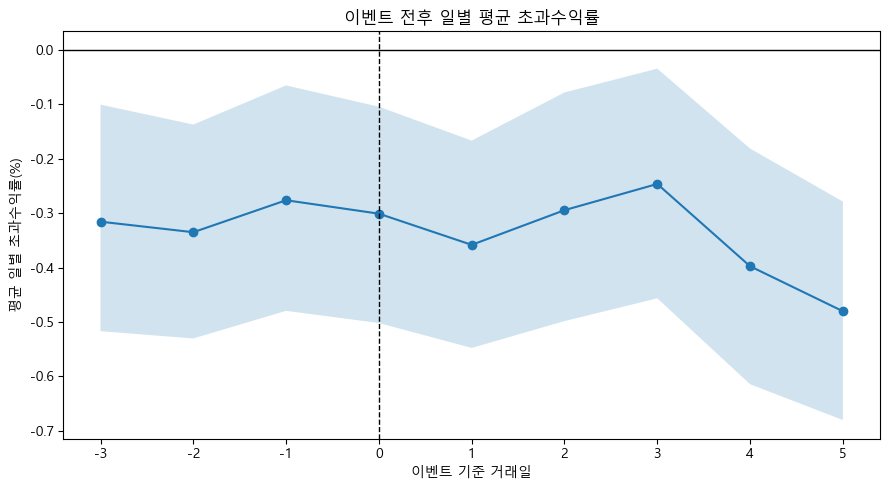

In [14]:
if not event_window_summary.empty:
    plot_data = event_window_summary.copy()

    plt.figure(figsize=(9, 5))
    plt.plot(plot_data["day_offset"], plot_data["mean_abret"] * 100, marker="o")
    plt.fill_between(
        plot_data["day_offset"],
        plot_data["ci_low"] * 100,
        plot_data["ci_high"] * 100,
        alpha=0.2
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linewidth=1, linestyle="--")
    plt.title("이벤트 전후 일별 평균 초과수익률")
    plt.xlabel("이벤트 기준 거래일")
    plt.ylabel("평균 일별 초과수익률(%)")
    plt.tight_layout()
    plt.show()
else:
    print("이벤트 스터디 그래프를 그릴 데이터가 없습니다.")


## 10. 제목 방향성별 반응

이벤트 유형만으로는 뉴스의 방향성을 충분히 구분하기 어렵습니다.  
예를 들어 같은 `실적` 뉴스라도 호실적과 실적 부진은 전혀 다른 의미를 가질 수 있습니다.

따라서 제목 안의 긍정·부정 단어를 기준으로 간단한 방향성 점수를 계산하고, 방향성별 초과수익률 차이도 함께 확인하였습니다. 이 지표는 정교한 감성 분석 모델은 아니지만, 이벤트 분류 결과를 해석할 때 참고할 수 있는 보조 변수로 사용하였습니다.


In [15]:
if not data.empty and "tone_label" in data.columns:
    tone_summary = data.groupby("tone_label").agg(
        sample_count=("abret_3d", "size"),
        abret_1d_mean=("abret_1d", "mean"),
        abret_3d_mean=("abret_3d", "mean"),
        abret_5d_mean=("abret_5d", "mean"),
        up_ratio_3d=("abret_3d", up_ratio)
    ).reset_index()

    tone_summary = tone_summary.sort_values("abret_3d_mean", ascending=False)

    display(tone_summary.round(4))
else:
    tone_summary = pd.DataFrame()
    print("방향성별로 비교할 데이터가 없습니다.")

,tone_label,sample_count,abret_1d_mean,abret_3d_mean,abret_5d_mean,up_ratio_3d
0,긍정,225,-0.0014,-0.0034,-0.0149,0.4267
1,부정,89,-0.0045,-0.0090,-0.0185,0.3708
2,중립,543,-0.0047,-0.0127,-0.0212,0.3628


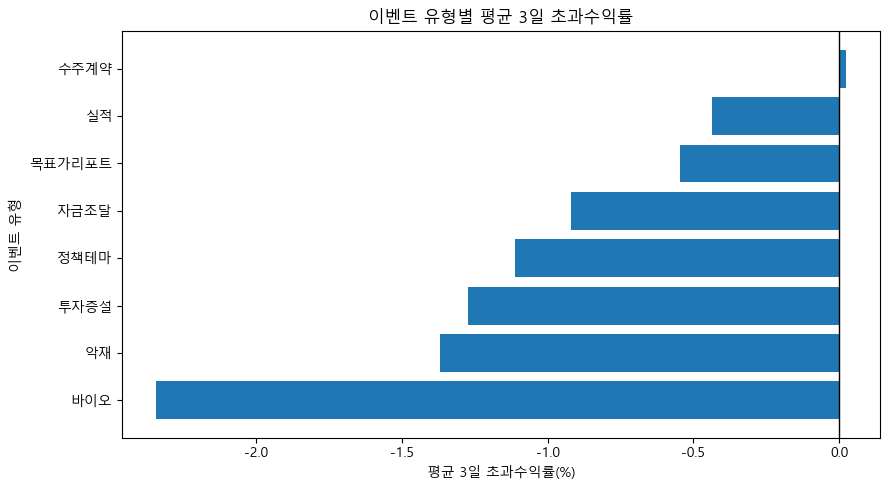

In [16]:
if not event_summary_filtered.empty:
    plot_data = event_summary_filtered.sort_values("abret_3d_mean")

    plt.figure(figsize=(9, 5))
    plt.barh(plot_data["main_event"], plot_data["abret_3d_mean"] * 100)
    plt.axvline(0, color="black", linewidth=1)
    plt.title("이벤트 유형별 평균 3일 초과수익률")
    plt.xlabel("평균 3일 초과수익률(%)")
    plt.ylabel("이벤트 유형")
    plt.tight_layout()
    plt.show()
else:
    print("그래프로 볼 이벤트 요약 데이터가 없습니다.")

<Figure size 1000x500 with 0 Axes>

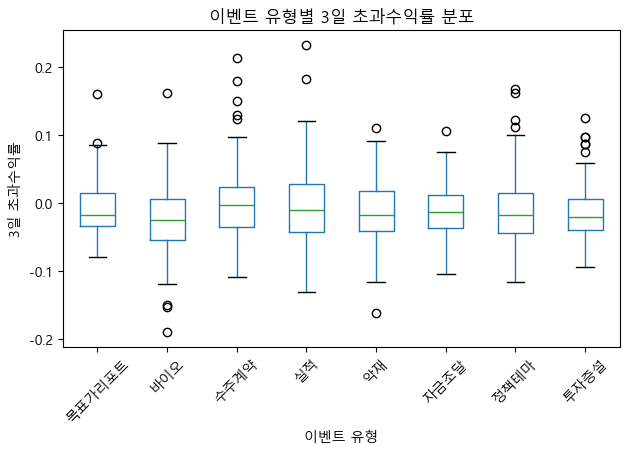

In [17]:
if not data.empty:
    plt.figure(figsize=(10, 5))
    data.boxplot(column="abret_3d", by="main_event", grid=False)
    plt.title("이벤트 유형별 3일 초과수익률 분포")
    plt.suptitle("")
    plt.xlabel("이벤트 유형")
    plt.ylabel("3일 초과수익률")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("박스플롯을 그릴 데이터가 없습니다.")

## 11. 선별 실험용 데이터 구성

모델은 3일 초과수익률을 기준으로 비교하였습니다. 수익률이 애매한 중간 구간은 제외하고, 상대적으로 좋았던 이벤트와 나빴던 이벤트를 나누어 분류 문제로 구성하였습니다.

특성에는 이벤트 개수, 이벤트 유형, 직전 주가 흐름, 거래량 비율, 제목 방향성 점수를 사용하였습니다.  
현재 데이터 수가 충분히 크지 않기 때문에, 모델 결과는 완성된 예측 모델의 성능이라기보다 이벤트 정보가 단기 초과수익률 선별에 신호를 줄 수 있는지 확인하는 탐색적 실험으로 해석하였습니다.


In [18]:
if data.empty:
    model_data = pd.DataFrame()
    print("모델에 사용할 데이터가 없습니다.")
else:
    base_model_data = data.sort_values("date").reset_index(drop=True).copy()

    raw_split_idx = int(len(base_model_data) * 0.75)
    train_raw = base_model_data.iloc[:raw_split_idx].copy()
    test_raw = base_model_data.iloc[raw_split_idx:].copy()

    # 타깃 기준선은 학습 구간에서만 계산합니다.
    # 테스트 구간 정보를 기준선 계산에 사용하지 않기 위한 처리입니다.
    low_line = train_raw["abret_3d"].quantile(0.4)
    high_line = train_raw["abret_3d"].quantile(0.6)

    train_model = train_raw[
        (train_raw["abret_3d"] <= low_line) |
        (train_raw["abret_3d"] >= high_line)
    ].copy()

    test_model = test_raw[
        (test_raw["abret_3d"] <= low_line) |
        (test_raw["abret_3d"] >= high_line)
    ].copy()

    train_model["target"] = (train_model["abret_3d"] >= high_line).astype(int)
    test_model["target"] = (test_model["abret_3d"] >= high_line).astype(int)

    model_data = pd.concat([train_model, test_model], ignore_index=True)
    split_idx = len(train_model)

    feature_cols = [
        "news_count",
        "event_score_sum",
        "event_word_count_sum",
        "tone_score_sum",
        "tone_score_mean",
        "positive_news_count",
        "negative_news_count",
        "past_ret_1d",
        "past_ret_5d",
        "volume_ratio_5d"
    ] + event_cols

    for col in feature_cols:
        if col not in model_data.columns:
            model_data[col] = 0

    X = model_data[feature_cols].fillna(0)
    y = model_data["target"]

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    print("기준 계산에 사용한 학습 원자료:", len(train_raw))
    print("검증 원자료:", len(test_raw))
    print("모델 데이터 행 수:", len(model_data))
    print("학습 데이터:", len(X_train), "테스트 데이터:", len(X_test))
    print("학습 구간 기준 하위선:", round(low_line * 100, 4), "%")
    print("학습 구간 기준 상위선:", round(high_line * 100, 4), "%")
    print("타깃 비율")
    display(y.value_counts(normalize=True))


기준 계산에 사용한 학습 원자료: 642
검증 원자료: 215
모델 데이터 행 수: 701
학습 데이터: 514 테스트 데이터: 187
학습 구간 기준 하위선: -2.3969 %
학습 구간 기준 상위선: -0.2324 %
타깃 비율


target
0    0.514979
1    0.485021
Name: proportion, dtype: float64

## 12. 기본 모델 비교

기준선 모델과 기본적인 분류 모델을 비교하였습니다. 복잡한 모델을 많이 사용하는 것보다, 단순한 기준선보다 나아지는지 확인하는 데 초점을 두었습니다.

데이터의 시계열 성격을 고려하여 무작위 분할은 사용하지 않았습니다. 날짜 순서상 앞부분을 학습 구간으로, 뒷부분을 테스트 구간으로 사용하였습니다.


In [19]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=120,
        max_depth=4,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

results = []
trained_models = {}
best_model_name = None
best_model = None

if model_data.empty or len(model_data) < MODEL_MIN_ROWS:
    results_df = pd.DataFrame()
    print("모델을 비교하기에는 데이터가 부족합니다.")
elif len(X_test) == 0:
    results_df = pd.DataFrame()
    print("테스트 데이터가 없어서 모델을 비교하기 어렵습니다.")
elif y_train.nunique() < 2:
    results_df = pd.DataFrame()
    print("학습 데이터에 한쪽 클래스만 있어서 모델을 비교하기 어렵습니다.")
else:
    for model_name, model in models.items():
        try:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            if hasattr(model, "predict_proba"):
                prob = model.predict_proba(X_test)[:, 1]
            else:
                prob = None

            if y_test.nunique() >= 2 and prob is not None:
                auc = roc_auc_score(y_test, prob)
            else:
                auc = np.nan

            results.append({
                "model": model_name,
                "accuracy": accuracy_score(y_test, pred),
                "precision": precision_score(y_test, pred, zero_division=0),
                "recall": recall_score(y_test, pred, zero_division=0),
                "f1": f1_score(y_test, pred, zero_division=0),
                "roc_auc": auc
            })

            trained_models[model_name] = model

        except Exception as e:
            print(model_name, "오류:", e)

    results_df = pd.DataFrame(results)

    if not results_df.empty:
        results_df = results_df.sort_values(
            ["roc_auc", "f1", "accuracy"],
            ascending=False,
            na_position="last"
        ).reset_index(drop=True)

        non_dummy = results_df[results_df["model"] != "Dummy"].copy()

        if not non_dummy.empty:
            best_model_name = non_dummy.iloc[0]["model"]
            best_model = trained_models[best_model_name]

        display(results_df)
    else:
        print("모델 결과가 생성되지 않았습니다.")


,model,accuracy,precision,recall,f1,roc_auc
0,GradientBoosting,0.556150,0.500000,0.506024,0.502994,0.593837
1,LogisticRegression,0.561497,0.505263,0.578313,0.539326,0.581789
2,RandomForest,0.540107,0.481013,0.457831,0.469136,0.572521
3,Dummy,0.556150,0.000000,0.000000,0.000000,0.500000


## 12-1. 모델 결과 해석 기준

모델 결과는 기준선보다 일부 지표가 좋아 보이더라도 보수적으로 해석하였습니다. 테스트 데이터가 많지 않으면 한두 건의 예측 차이만으로 정확도, F1 점수, AUC가 크게 움직일 수 있기 때문입니다.

이 단계의 목적은 좋은 매매 모델을 완성하는 것이 아닙니다. 뉴스 이벤트 유형, 제목 방향성, 직전 주가 흐름이 이후 초과수익률 구분에 어느 정도 정보를 제공하는지 확인하는 데 있습니다. 변수 중요도는 모델이 어떤 입력값을 상대적으로 많이 참고했는지 확인하는 보조 자료로 사용하였습니다.


In [20]:
feature_importance = pd.DataFrame()

if best_model is not None and hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(feature_importance.head(10))
elif best_model is not None:
    print(best_model_name, "모델은 변수 중요도를 바로 제공하지 않습니다.")
else:
    print("변수 중요도를 확인할 모델 결과가 없습니다.")

,feature,importance
8,past_ret_5d,0.205434
9,volume_ratio_5d,0.182323
7,past_ret_1d,0.168938
4,tone_score_mean,0.112532
12,event_수주계약,0.062805
2,event_word_count_sum,0.056054
1,event_score_sum,0.043872
15,event_목표가리포트,0.029529
10,event_악재,0.025805
3,tone_score_sum,0.024519


## 13. 모델이 선별한 이벤트의 실제 반응

분류 지표만으로는 투자 관점의 의미를 판단하기 어렵습니다.  
따라서 모델이 긍정적으로 판단한 상위 이벤트의 실제 평균 초과수익률이 테스트 전체보다 나아졌는지도 함께 확인하였습니다.

이 비교가 좋아야 모델이 단순히 라벨을 맞힌 것을 넘어, 상대적으로 좋은 이벤트를 어느 정도 선별했다고 볼 수 있습니다.


In [21]:
if "results_df" in globals() and not results_df.empty and best_model is not None:
    test_result = model_data.iloc[split_idx:].copy()

    if len(test_result) == 0:
        compare_result = pd.DataFrame()
        print("테스트 데이터가 없어서 상위 이벤트 비교를 건너뜁니다.")
    elif hasattr(best_model, "predict_proba"):
        test_result["pred_prob"] = best_model.predict_proba(X_test)[:, 1]

        cutoff = test_result["pred_prob"].quantile(0.8)
        selected = test_result[test_result["pred_prob"] >= cutoff].copy()

        compare_result = pd.DataFrame({
            "구분": ["테스트 전체 이벤트", "모델 선택 상위 20%"],
            "표본 수": [len(test_result), len(selected)],
            "평균 3일 초과수익률(%)": [
                test_result["abret_3d"].mean() * 100,
                selected["abret_3d"].mean() * 100
            ],
            "3일 초과수익률 양수 비율": [
                (test_result["abret_3d"] > 0).mean(),
                (selected["abret_3d"] > 0).mean()
            ]
        })

        print("사용 모델:", best_model_name)
        display(compare_result.round(4))

        selected_cols = [
            "date", "name", "main_event", "tone_label",
            "pred_prob", "abret_3d", "sample_titles"
        ]

        display(selected[selected_cols].sort_values("pred_prob", ascending=False).head(10))
    else:
        compare_result = pd.DataFrame()
        print("선택된 모델이 확률값을 제공하지 않아 상위 이벤트 비교를 건너뜁니다.")
else:
    compare_result = pd.DataFrame()
    print("모델 결과가 없어서 상위 이벤트 비교를 건너뜁니다.")


사용 모델: GradientBoosting


,구분,표본 수,평균 3일 초과수익률(%),3일 초과수익률 양수 비율
0,테스트 전체 이벤트,187,-0.9655,0.4064
1,모델 선택 상위 20%,38,-0.2850,0.5789


,date,name,main_event,tone_label,pred_prob,abret_3d,sample_titles
576,2026-04-15,알테오젠,목표가리포트,긍정,0.880905,-0.024985,외인·기관 쌍끌이에 코스피 6140선…코스닥 바이오도 급등[마켓시그..... / 코...
622,2026-04-16,아모레퍼시픽,수주계약,긍정,0.876755,-0.045607,"바운드포, 1분기 수주 5.3배 급증…에이전틱 AI 데이터로 성장 가속"
685,2026-04-20,KT,실적,긍정,0.870384,-0.054018,"[단독] KT, 차기 CEO 승계 규정 만든다…박윤영 대표 경영계약서... / 방미..."
558,2026-04-15,삼성물산,수주계약,긍정,0.868679,-0.045354,"삼성물산, ‘AI 웰니스 설루션’ 출시에 강북삼성병원과 협력 / ""AI가 맞춤형 웰..."
692,2026-04-20,현대로템,목표가리포트,긍정,0.867229,0.036524,"현대로템, 국내 3대 신용평가사 신용등급 'AA-'로 상향 / 현대로템, 국내 3대..."
651,2026-04-17,에코프로,악재,중립,0.815967,0.045132,"코스피, 美·이란 종전 협상 기대·우려 공존하며 약보합세 / 양대 증시 장초반 혼조..."
617,2026-04-16,HLB,목표가리포트,긍정,0.797187,-0.046495,"진양곤 의장, HLB제넥스 지분 장내매수..올해 벌써 7번째 매입 / 진양곤 의장,..."
551,2026-04-14,하이브,악재,부정,0.778742,0.031683,"BTS 컴백 한 달, 미동 없는 엔터주에 증권사는 줄줄이 목표주가 하향... / '..."
568,2026-04-15,크래프톤,악재,중립,0.777114,0.050757,"증시 반등에도 부진한 ' K콘텐츠'…증권가 ""하반기 모멘텀 기대"" / K-게임 양극..."
556,2026-04-15,카카오페이,실적,중립,0.757975,0.017639,"진격의 코나아이… 1분기 매출 766억·영업익 246억 / 코나아이, 1분기 매출 ..."


## 13-1. 선택 이벤트 비교 해석

모델이 선별한 상위 이벤트의 양수 비율과 평균 초과수익률을 테스트 전체와 비교하였습니다.  
양수 비율이 높더라도 평균 초과수익률이 낮다면 실제로 좋은 이벤트를 골라냈다고 보기 어렵습니다.

상위 20% 표본은 일반적으로 매우 적게 남기 때문에 결과가 좋아 보여도 과도하게 일반화하지 않았습니다. 이 비교는 실전 매매 검증이 아니라 이벤트 정보의 선별 가능성을 확인하는 참고 분석으로 사용하였습니다.


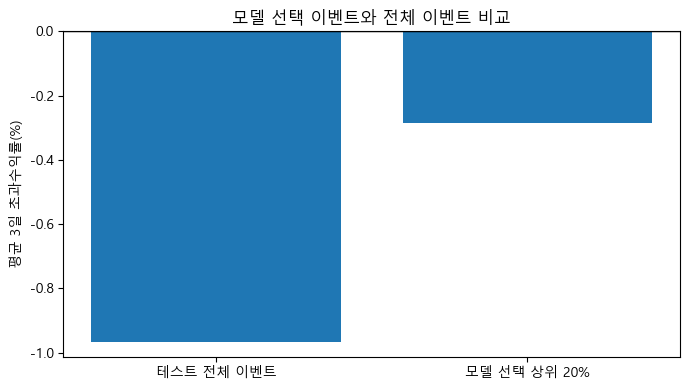

In [22]:
if "compare_result" in globals() and not compare_result.empty:
    plt.figure(figsize=(7, 4))
    plt.bar(compare_result["구분"], compare_result["평균 3일 초과수익률(%)"])
    plt.axhline(0, color="black", linewidth=1)
    plt.title("모델 선택 이벤트와 전체 이벤트 비교")
    plt.ylabel("평균 3일 초과수익률(%)")
    plt.tight_layout()
    plt.show()
else:
    print("그래프로 표시할 비교 결과가 없습니다.")

## 14. 종합 해석

본 프로젝트에서는 국내 주요 종목의 뉴스 제목을 이벤트 유형으로 분류하고, 이벤트 이후 단기 초과수익률을 비교하는 이벤트 스터디를 진행하였습니다. 핵심은 뉴스가 나온 뒤 주가가 단순히 상승했는지가 아니라, 같은 기간의 시장 흐름을 제외하고도 종목 고유의 반응이 나타났는지를 확인하는 데 있습니다.

분석 결과를 볼 때 가장 먼저 확인할 부분은 이벤트 유형별 평균 초과수익률과 양수 비율입니다. 평균값이 양수라도 신뢰구간이 넓거나 표본 수가 적으면 일반화하기 어렵습니다. 반대로 평균값이 음수이고 표본도 어느 정도 확보되어 있다면, 해당 이벤트가 단기적으로 시장 대비 부진한 흐름과 연결될 가능성을 생각해볼 수 있습니다.

이벤트 스터디에서는 이벤트 기준일 전후의 일별 평균 초과수익률과 누적 초과수익률을 확인하였습니다. 이벤트 기준일 주변에서 평균 초과수익률이 뚜렷하게 변하는지, 누적 초과수익률이 어느 구간에서 커지는지 보는 것이 중요합니다.

모델 비교는 마지막 보조 분석으로 사용하였습니다. 기준선 모델보다 일부 지표가 좋아 보이더라도 테스트 표본이 작으면 안정적인 예측 성능이라고 보기 어렵습니다. 따라서 모델 결과는 투자 전략의 결론이 아니라, 이벤트 정보와 직전 주가 흐름이 단기 초과수익률을 구분하는 데 어느 정도 참고가 되는지 확인하는 정도로 해석하였습니다.

정리하면, 본 분석은 뉴스 이벤트가 항상 긍정적인 가격 반응으로 이어지는지 확인하는 프로젝트가 아닙니다. 오히려 뉴스가 공개되는 시점에 기대가 이미 가격에 반영되어 있거나, 이벤트 이후 차익실현이 나타날 수 있다는 점까지 함께 확인하는 탐색적 분석입니다.


In [23]:
summary_rows = []

if "news_all" in globals():
    summary_rows.append(["전체 수집 뉴스", len(news_all)])

if "news_event" in globals():
    summary_rows.append(["이벤트로 분류된 뉴스", len(news_event)])

if "data" in globals() and not data.empty:
    summary_rows.append(["분석용 일 단위 이벤트", len(data)])
    summary_rows.append(["분석 시작일", data["date"].min().date()])
    summary_rows.append(["분석 종료일", data["date"].max().date()])

if "event_window_data" in globals() and not event_window_data.empty:
    summary_rows.append(["이벤트 스터디 사용 데이터", len(event_window_data)])

if "model_data" in globals() and not model_data.empty:
    summary_rows.append(["모델 사용 데이터", len(model_data)])

    if "X_test" in globals():
        summary_rows.append(["테스트 데이터", len(X_test)])

project_summary = pd.DataFrame(summary_rows, columns=["항목", "값"])
display(project_summary)

if "event_summary_filtered" in globals() and not event_summary_filtered.empty:
    final_event_summary = event_summary_filtered[[
        "main_event", "sample_count", "abret_1d_mean",
        "abret_3d_mean", "abret_5d_mean", "up_ratio_3d",
        "abret_3d_ci_low", "abret_3d_ci_high", "abret_3d_p_value"
    ]].copy()

    final_event_summary = format_percent_columns(
        final_event_summary,
        [
            "abret_1d_mean", "abret_3d_mean", "abret_5d_mean",
            "up_ratio_3d", "abret_3d_ci_low", "abret_3d_ci_high"
        ]
    )

    print("이벤트별 최종 요약")
    display(final_event_summary.round(4))

if "car_summary" in globals() and not car_summary.empty:
    final_car_summary = format_percent_columns(
        car_summary,
        ["mean_car", "median_car", "up_ratio", "ci_low", "ci_high"]
    )

    print("이벤트 스터디 누적 초과수익률 요약")
    display(final_car_summary.round(4))


,항목,값
0,전체 수집 뉴스,15607
1,이벤트로 분류된 뉴스,5377
2,분석용 일 단위 이벤트,857
3,분석 시작일,2025-12-03
4,분석 종료일,2026-04-20
5,이벤트 스터디 사용 데이터,857
6,모델 사용 데이터,701
7,테스트 데이터,187


이벤트별 최종 요약


,main_event,sample_count,abret_1d_mean,abret_3d_mean,abret_5d_mean,up_ratio_3d,abret_3d_ci_low,abret_3d_ci_high,abret_3d_p_value
2,수주계약,142,-0.3265,0.0213,-0.5079,47.1831,-0.7788,0.8608,0.9610
3,실적,145,-0.1272,-0.4360,-0.8399,40.6897,-1.3491,0.5069,0.3630
0,목표가리포트,73,-0.2956,-0.5453,-2.0798,41.0959,-1.5288,0.5002,0.2779
5,자금조달,27,0.1856,-0.9202,-2.0495,40.7407,-2.5697,0.8775,0.2992
6,정책테마,102,-0.1490,-1.1129,-2.5801,36.2745,-2.0808,-0.0447,0.0370
7,투자증설,114,-0.4349,-1.2718,-1.6223,32.4561,-2.0066,-0.5465,0.0010
4,악재,134,-0.6492,-1.3698,-2.2890,35.8209,-2.1620,-0.5402,0.0009
1,바이오,120,-0.7744,-2.3402,-4.1153,30.8333,-3.2111,-1.4521,0.0000


이벤트 스터디 누적 초과수익률 요약


,window,sample_count,mean_car,median_car,up_ratio,ci_low,ci_high,t_stat,p_value
0,"CAR(-1,+1)",814,-0.9831,-1.4377,38.0835,-1.3276,-0.6489,-5.6323,0.0
1,"CAR(0,+1)",814,-0.6424,-1.0085,40.1720,-0.9228,-0.3642,-4.5235,0.0
2,"CAR(0,+3)",736,-1.2287,-1.4539,36.8207,-1.6224,-0.8557,-6.1791,0.0
3,"CAR(0,+5)",657,-2.1427,-2.0320,34.8554,-2.6656,-1.6222,-8.4295,0.0


## 15. 한계와 확장 방향

본 분석은 네이버 금융 뉴스 제목을 기반으로 하므로 기사 본문 전체의 문맥을 반영하지 못합니다. 또한 네이버 금융에서 실제로 수집되는 종목뉴스가 최근 기사 중심으로 제공되기 때문에, 뉴스 이벤트 분석 결과는 실제 수집된 뉴스 기간을 중심으로 해석해야 합니다.

이벤트 분류는 키워드 기반 규칙을 사용했기 때문에 일부 오분류가 발생할 수 있습니다. 예를 들어 부정 단어가 포함되어 있어도 기사 전체 맥락은 회복 기대나 사업 확장일 수 있습니다. 따라서 결과는 개별 뉴스의 정확한 감성 판단이라기보다, 동일한 규칙으로 분류한 이벤트 집단의 평균적 반응을 비교한 것으로 해석하였습니다.

후속 분석에서는 다음 방향으로 확장할 수 있습니다.

1. 뉴스 본문 또는 요약문을 함께 사용한 문맥 기반 분류
2. DART 공시 데이터와 뉴스 이벤트의 분리 비교
3. 더 긴 기간의 뉴스 데이터 확보를 통한 표본 확대
4. walk-forward validation을 통한 시계열 검증 강화
5. 거래비용과 체결 조건을 포함한 실제 전략 성과 검토

본 프로젝트의 목적은 완성된 투자 전략을 제시하는 것이 아니라, 뉴스 이벤트 유형과 단기 초과수익률 사이의 관계를 데이터 기반으로 탐색하는 것입니다.


## 16. 최종 해석 및 결론

본 프로젝트에서는 네이버 금융 종목뉴스를 수집한 뒤, 뉴스 제목을 기준으로 주요 이벤트 유형을 분류하고, 뉴스 발생 이후의 단기 초과수익률을 분석하였습니다.  
초과수익률은 개별 종목 수익률에서 KOSPI 수익률을 차감하여 계산하였으며, 단순한 주가 상승률이 아니라 같은 기간의 시장 흐름을 제외한 종목 고유의 반응을 확인하고자 하였습니다.

분석은 총 15,607건의 뉴스 데이터에서 출발하였습니다.  
이 중 키워드 기준으로 5,597건이 이벤트성 뉴스로 분류되었고, 거래일 매칭 이후 5,377건이 분석 가능한 이벤트 뉴스로 남았습니다.  
이후 동일 종목과 동일 거래일에 발생한 뉴스를 일 단위로 집계하여 최종적으로 857건의 분석용 이벤트 데이터를 구성하였습니다.

실제 수집된 뉴스 데이터의 기간은 2025년 12월 2일부터 2026년 4월 20일까지이며, 거래일 매칭과 일 단위 집계 이후 최종 분석용 이벤트 데이터의 기간은 2025년 12월 3일부터 2026년 4월 20일까지입니다.

### 1. 이벤트 유형별 결과 해석

이벤트 유형별 3일 평균 초과수익률을 비교한 결과, 모든 이벤트가 긍정적인 가격 반응으로 이어지지는 않았습니다.  
가장 양호한 흐름을 보인 유형은 `수주계약`이었으며, 평균 3일 초과수익률은 약 +0.02%로 나타났습니다.  
다만 이는 사실상 중립에 가까운 수준이고, 3일 초과수익률 양수 비율도 약 47.18%에 그쳤습니다.  
따라서 수주계약 뉴스라고 해서 항상 시장 대비 강한 수익률이 나타난다고 보기는 어렵습니다.

반면 `바이오`, `악재`, `투자증설`, `정책테마` 유형은 뉴스 발생 이후 평균 초과수익률이 비교적 낮게 나타났습니다.  
특히 `바이오` 이벤트는 평균 3일 초과수익률이 약 -2.34%, 5일 초과수익률이 약 -4.12%로 가장 부진한 흐름을 보였습니다.  
`악재`와 `투자증설` 역시 3일 평균 초과수익률이 각각 약 -1.37%, -1.27%로 나타났고, 통계적으로도 유의한 수준의 부정적 반응이 확인되었습니다.  
`정책테마` 역시 평균 3일 초과수익률이 약 -1.11%로 낮았으며, 단기적으로 기대감보다 차익실현이나 재료 소멸이 더 강하게 반영되었을 가능성이 있습니다.

이 결과는 뉴스 제목에 긍정적으로 보이는 단어가 포함되어 있더라도 실제 주가 반응은 다르게 나타날 수 있음을 보여줍니다.  
예를 들어 시장에서 이미 기대가 선반영되었거나, 뉴스 공개 이후 차익실현이 발생한 경우 긍정적인 뉴스 이후에도 초과수익률이 낮게 나타날 수 있습니다.

### 2. 이벤트 스터디 결과 해석

이벤트 스터디 결과에서도 뉴스 발생 전후의 누적 초과수익률은 전반적으로 음의 방향을 보였습니다.  
CAR(0,+1)은 약 -0.64%, CAR(0,+3)은 약 -1.23%, CAR(0,+5)는 약 -2.14%로 나타났습니다.  
특히 관찰 기간이 길어질수록 평균 누적 초과수익률이 더 낮아지는 경향이 확인되었습니다.

CAR(0,+5)의 양수 비율은 약 34.86%였습니다.  
즉, 이벤트 이후 5거래일 동안 시장 대비 초과수익률이 양수였던 경우보다 음수였던 경우가 더 많았습니다.  
이는 뉴스 이벤트가 단기적으로 항상 긍정적인 투자 신호가 되지는 않으며, 오히려 이벤트 발생 이후 기대 소멸이나 차익실현이 나타날 수 있음을 시사합니다.

또한 이벤트 발생 전 -3일, -2일, -1일 구간에서도 평균 초과수익률이 음수로 나타났습니다.  
이는 일부 종목의 경우 뉴스 발생 전부터 이미 주가 흐름이 약했거나, 시장 대비 부진한 상태에서 뉴스가 발생했을 가능성을 보여줍니다.

### 3. 제목 방향성별 결과 해석

뉴스 제목의 방향성을 `긍정`, `중립`, `부정`으로 나누어 비교한 결과, 긍정 뉴스가 반드시 높은 초과수익률로 이어지지는 않았습니다.  
긍정으로 분류된 뉴스의 평균 3일 초과수익률은 약 -0.34%였고, 부정 뉴스는 약 -0.90%, 중립 뉴스는 약 -1.27%였습니다.  
긍정 뉴스가 상대적으로 덜 부진하기는 했지만, 평균값 자체는 여전히 음수였습니다.

이는 제목의 단순한 긍정·부정 분류만으로는 이후 주가 반응을 충분히 설명하기 어렵다는 점을 보여줍니다.  
실제 투자 판단에서는 뉴스의 방향성뿐 아니라 이벤트 유형, 직전 주가 흐름, 시장 기대 반영 여부, 거래대금, 섹터 흐름 등을 함께 고려할 필요가 있습니다.

### 4. 모델링 결과 해석

뉴스 이벤트 정보가 이후 초과수익률이 상대적으로 좋은 이벤트를 구분하는 데 도움이 되는지도 간단한 분류 모델을 통해 확인하였습니다.  
모델에는 이벤트 유형, 뉴스 제목의 방향성, 직전 수익률 흐름, 거래량 변화 등을 변수로 사용하였고, 시간 순서를 고려하여 학습 데이터와 테스트 데이터를 분리하였습니다.

ROC-AUC 기준으로 가장 좋은 성능을 보인 모델은 `GradientBoosting`이었으며, 테스트 데이터 기준 ROC-AUC는 약 0.594로 Dummy 모델의 0.500보다 높게 나타났습니다.  
다만 정확도는 약 0.556으로 Dummy 모델과 동일했고, F1 기준에서는 `LogisticRegression`이 더 높게 나타났습니다.  
따라서 특정 모델이 강하게 우수하다고 판단하기는 어렵고, 전체적으로는 예측력이 제한적인 탐색적 모델로 해석하는 것이 적절하다고 생각합니다.

추가로 모델이 긍정적으로 판단한 상위 20% 이벤트를 따로 비교한 결과, 테스트 전체 이벤트의 평균 3일 초과수익률은 약 -0.97%였고, 모델 선택 상위 20%는 약 -0.29%였습니다.  
또한 3일 초과수익률 양수 비율도 테스트 전체는 약 40.64%, 모델 선택 상위 20%는 약 57.89%로 개선되었습니다.  
이 점은 모델이 일부 이벤트를 상대적으로 더 잘 선별했을 가능성을 보여줍니다.

다만 모델 선택 상위 20%의 표본 수는 38건으로 많지 않습니다.  
따라서 이 결과를 일반화하기에는 한계가 있으며, 실제 매매 전략으로 사용하기 위해서는 더 긴 기간의 데이터와 추가 검증이 필요합니다.

### 5. 한계점

본 분석은 뉴스 제목을 기준으로 이벤트를 분류하였기 때문에 기사 본문 전체의 맥락이나 실제 기업 공시 내용을 완전히 반영하지는 못했습니다.  
또한 같은 뉴스 제목 안에 여러 기업, 산업, 시장 전체 이슈가 함께 포함될 수 있어, 특정 종목에 대한 직접적인 이벤트로 보기 어려운 경우도 일부 존재할 수 있습니다.

분석 기간 역시 약 4개월 정도의 최근 뉴스에 기반하고 있으므로, 시장 국면이 달라졌을 때 동일한 결과가 반복된다고 단정하기는 어렵습니다.  
특히 이벤트 유형별 표본 수가 충분히 크지 않은 경우에는 평균값이 일부 극단적인 사례의 영향을 받을 수 있습니다.

추후에는 분석 기간을 더 길게 확장하고, 뉴스 제목뿐 아니라 기사 본문, 공시 데이터, 섹터 지표, 수급 데이터, 거래대금 변화 등을 함께 반영할 필요가 있습니다.  
또한 이벤트 유형 간 차이를 더 엄밀하게 판단하기 위해서는 단순 평균 비교뿐 아니라 추가적인 통계 검정과 시계열 검증도 필요합니다.

### 6. 최종 결론

이번 분석을 통해 국내 주식시장에서 뉴스 이벤트가 발생한 이후의 단기 주가 반응은 이벤트 유형에 따라 서로 다른 양상을 보인다는 점을 확인하였습니다.  
다만 뉴스가 긍정적으로 보인다고 해서 반드시 시장 대비 초과수익률이 좋아지는 것은 아니었습니다.

특히 `바이오`, `악재`, `투자증설`, `정책테마` 관련 뉴스는 단기적으로 부정적인 초과수익률을 보이는 경우가 많았습니다.  
반면 `수주계약` 뉴스는 상대적으로 가장 양호했지만, 평균 초과수익률이 거의 중립에 가까웠고 통계적으로 뚜렷한 초과수익을 보장하는 수준은 아니었습니다.

따라서 뉴스 이벤트는 단독 투자 판단 기준으로 사용하기보다는, 이벤트 유형, 시장 기대 반영 여부, 직전 주가 흐름, 거래대금, 섹터 흐름 등을 함께 고려하는 보조 지표로 활용하는 것이 적절하다고 판단됩니다.  
본 프로젝트는 뉴스 데이터를 정량화하여 이벤트별 단기 주가 반응을 비교하고, 이를 바탕으로 간단한 선별 모델까지 실험했다는 점에서 의미가 있다고 생각합니다.